## Libary

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelextrema

## Importing data

In [3]:
df = pd.read_csv("FTSE 100 Historical Data (3).csv")
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/31/2025,"9,931.38","9,940.70","9,950.11","9,916.70",176.05M,-0.09%
1,12/30/2025,"9,940.71","9,866.53","9,954.32","9,859.77",364.74M,0.75%
2,12/29/2025,"9,866.53","9,870.69","9,892.79","9,858.46",341.17M,-0.04%
3,12/24/2025,"9,870.68","9,889.20","9,893.15","9,862.04",163.41M,-0.19%
4,12/23/2025,"9,889.22","9,865.94","9,901.48","9,846.29",534.19M,0.24%


In [4]:
df.tail()

,Date,Price,Open,High,Low,Vol.,Change %
753,01/09/2023,"7,724.94","7,699.49","7,725.74","7,688.69",844.76M,0.33%
754,01/06/2023,"7,699.49","7,633.45","7,700.81","7,633.45",787.76M,0.87%
755,01/05/2023,"7,633.45","7,585.19","7,658.79","7,564.70",883.30M,0.64%
756,01/04/2023,"7,585.19","7,554.09","7,609.25","7,545.18",748.68M,0.41%
757,01/03/2023,"7,554.09","7,451.74","7,626.40","7,448.69",913.39M,1.37%


## Understanding Data 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      758 non-null    object
 1   Price     758 non-null    object
 2   Open      758 non-null    object
 3   High      758 non-null    object
 4   Low       758 non-null    object
 5   Vol.      758 non-null    object
 6   Change %  758 non-null    object
dtypes: object(7)
memory usage: 41.6+ KB


In [6]:
# Check which rows have 'B'
billion_rows = df[df['Vol.'].str.endswith('B')]
print(billion_rows)

           Date     Price      Open      High       Low   Vol. Change %
6    12/19/2025  9,897.42  9,837.76  9,903.13  9,819.44  1.61B    0.61%
25   11/24/2025  9,534.91  9,539.72  9,592.55  9,524.74  1.67B   -0.05%
39   11/04/2025  9,714.96  9,701.40  9,714.96  9,574.15  1.02B    0.14%
48   10/22/2025  9,515.00  9,427.05  9,545.23  9,427.05  1.02B    0.93%
71   09/19/2025  9,216.67  9,228.11  9,250.99  9,207.70  1.72B   -0.12%
..          ...       ...       ...       ...       ...    ...      ...
717  02/28/2023  7,876.28  7,935.11  7,935.11  7,854.82  1.25B   -0.74%
724  02/17/2023  8,004.36  8,012.53  8,012.53  7,957.69  1.27B   -0.10%
730  02/09/2023  7,911.15  7,885.17  7,949.57  7,874.23  1.03B    0.33%
738  01/30/2023  7,784.87  7,765.15  7,790.69  7,718.33  1.12B    0.25%
751  01/11/2023  7,724.98  7,694.49  7,772.37  7,694.35  1.03B    0.40%

[141 rows x 7 columns]


In [7]:
num_billion = df['Vol.'].str.endswith('B').sum()
print(f"Number of rows in billions: {num_billion}")

Number of rows in billions: 141


### Changing Datatypes 

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

In [9]:
# List of columns to convert
cols = ['Price', 'Open', 'High', 'Low']

# Remove commas and convert to float
for col in cols:
    df[col] = df[col].apply(lambda x: float(str(x).replace(',', '')) if pd.notna(x) else 0.0)


In [10]:
#Converting Vol.
def convert_volume(vol):
    if pd.isna(vol):
        return 0.0
    # If already numeric, return as is
    if isinstance(vol, (int, float)):
        return vol
    vol = str(vol).strip()  # make sure it's a string
    if vol.endswith('M'):
        return float(vol[:-1].replace(',', '')) * 1e6
    elif vol.endswith('B'):
        return float(vol[:-1].replace(',', '')) * 1e9
    elif vol.endswith('K'):
        return float(vol[:-1].replace(',', '')) * 1e3
    else:
        return float(vol.replace(',', ''))
    
df['Vol.'] = df['Vol.'].apply(convert_volume)

In [11]:
#Convert Change %
def convert_change(val):
    if pd.isna(val):
        return 0.0
    # If already numeric, return as float
    if isinstance(val, (int, float)):
        return float(val)
    # Otherwise, remove % and convert
    return float(str(val).replace('%',''))

df['Change %'] = df['Change %'].apply(convert_change)

In [12]:
df.dtypes

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object

## Exploratory Data Analysis

In [13]:
df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,758,758.00000,758.000000,758.000000,758.000000,7.580000e+02,758.000000
mean,2024-07-02 07:07:26.437994496,8229.96967,8226.726623,8266.571003,8191.677982,8.223030e+08,0.040237
min,2023-01-03 00:00:00,7256.94000,7256.940000,7280.500000,7206.820000,1.634100e+08,-4.950000
25%,2023-10-03 06:00:00,7673.02000,7670.172500,7698.920000,7633.330000,6.453500e+08,-0.300000
50%,2024-07-03 12:00:00,8167.73500,8166.820000,8208.470000,8138.160000,7.715150e+08,0.070000
75%,2025-03-31 18:00:00,8658.94750,8655.857500,8692.055000,8613.927500,9.446525e+08,0.410000
max,2025-12-31 00:00:00,9940.71000,9940.700000,9954.320000,9916.700000,2.580000e+09,3.040000
std,NaN,664.36374,662.009061,661.905254,663.626208,2.856826e+08,0.695306


In [14]:
df.isna().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

### Plot Trends 

In [15]:
# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

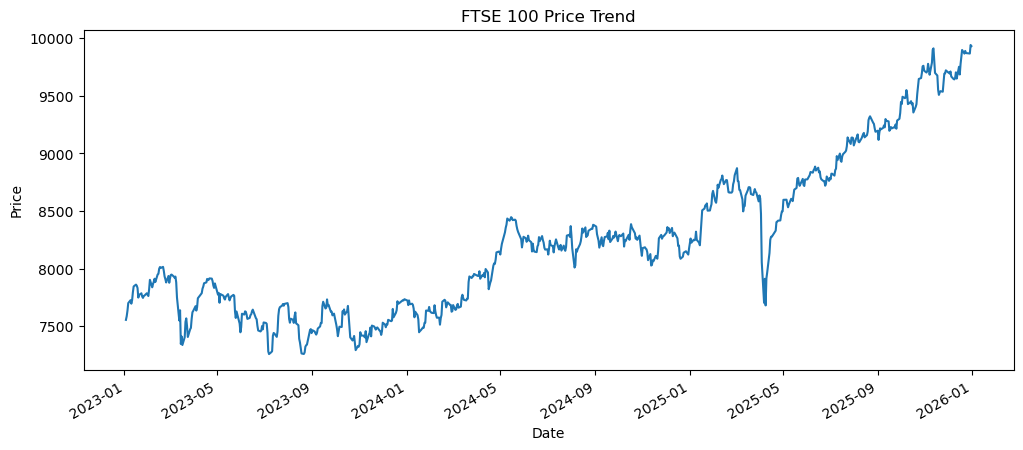

In [16]:
#Price trends 
df['Price'].plot(figsize=(12,5), title='FTSE 100 Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

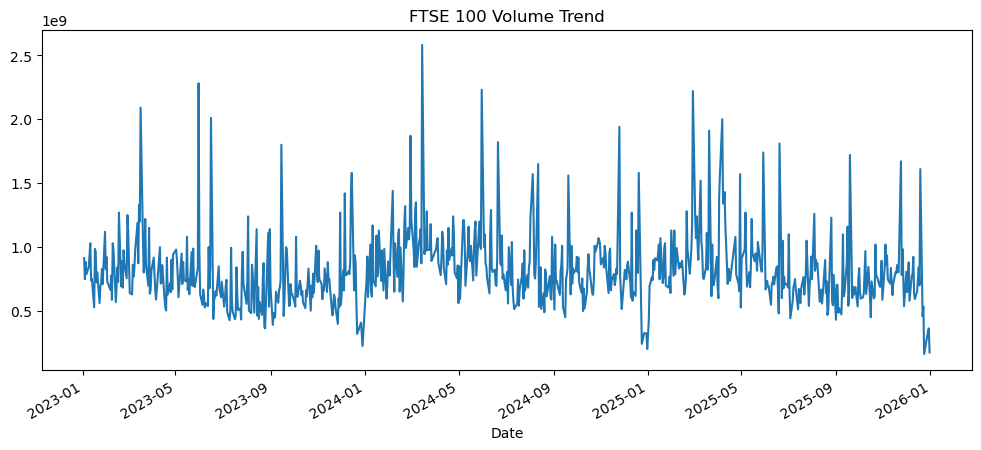

In [17]:
# Volume trend
df['Vol.'].plot(figsize=(12,5), title='FTSE 100 Volume Trend')
plt.show()

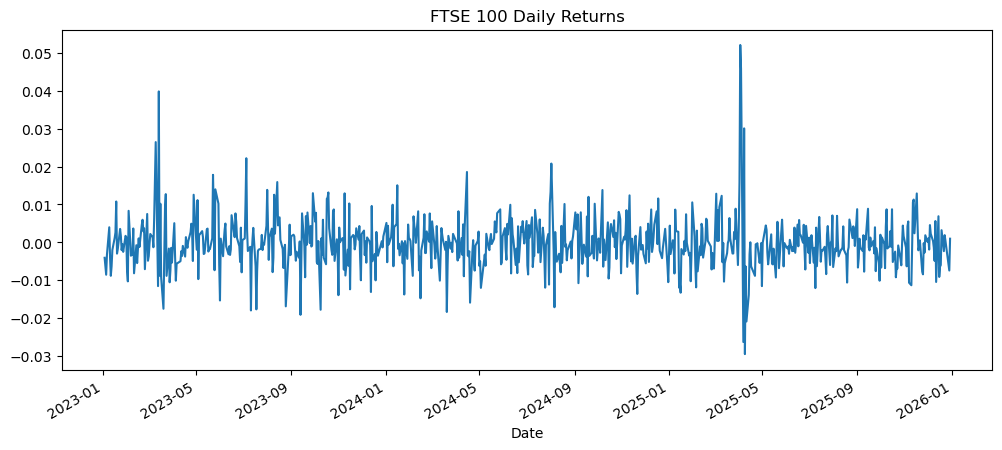

In [18]:
# Daily returns
df['Returns'] = df['Price'].pct_change()

# Plot returns
df['Returns'].plot(figsize=(12,5), title='FTSE 100 Daily Returns')
plt.show()

In [19]:
df['Returns'].describe()

count    757.000000
mean      -0.000337
std        0.006991
min       -0.029542
25%       -0.004067
50%       -0.000675
75%        0.003057
max        0.052112
Name: Returns, dtype: float64

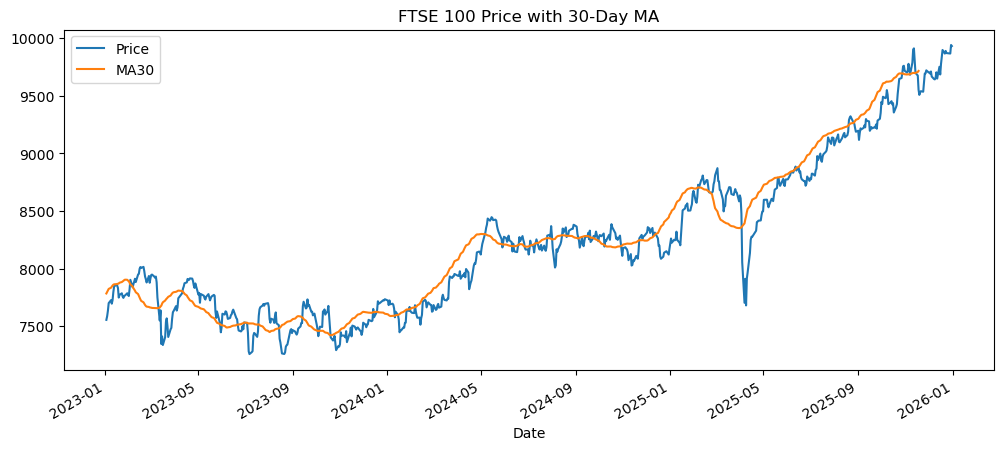

In [20]:
# 30-day moving average
df['MA30'] = df['Price'].rolling(30).mean()

# 30-day rolling volatility (std of returns)
df['Volatility'] = df['Returns'].rolling(30).std()

# Plot moving average
df[['Price', 'MA30']].plot(figsize=(12,5), title='')
plt.show()

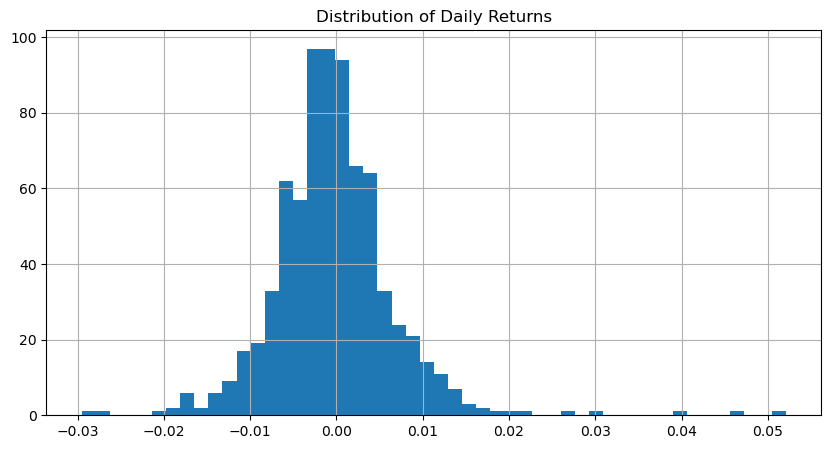

In [21]:
df['Returns'].hist(bins=50, figsize=(10,5))
plt.title('Distribution of Daily Returns')
plt.show()

In [22]:
df.corr()

,Price,Open,High,Low,Vol.,Change %,Returns,MA30,Volatility
Price,1.000000,0.996421,0.998429,0.998844,-0.048264,0.074451,0.005475,0.968267,-0.073137
Open,0.996421,1.000000,0.998236,0.997671,-0.039865,-0.009725,0.010259,0.965322,-0.062196
High,0.998429,0.998236,1.000000,0.997856,-0.033133,0.034809,0.009253,0.969381,-0.064767
Low,0.998844,0.997671,0.997856,1.000000,-0.053743,0.046068,0.008944,0.965087,-0.074389
Vol.,-0.048264,-0.039865,-0.033133,-0.053743,1.000000,-0.098674,0.003993,0.001337,0.114604
Change %,0.074451,-0.009725,0.034809,0.046068,-0.098674,1.000000,-0.047912,0.052826,-0.115503
Returns,0.005475,0.010259,0.009253,0.008944,0.003993,-0.047912,1.000000,-0.050849,0.151336
MA30,0.968267,0.965322,0.969381,0.965087,0.001337,0.052826,-0.050849,1.000000,-0.192577
Volatility,-0.073137,-0.062196,-0.064767,-0.074389,0.114604,-0.115503,0.151336,-0.192577,1.000000


In [23]:
df.head()

,Price,Open,High,Low,Vol.,Change %,Returns,MA30,Volatility
Date,,,,,,,,,
2025-12-31,9931.38,9940.70,9950.11,9916.70,176050000.0,-0.09,NaN,NaN,NaN
2025-12-30,9940.71,9866.53,9954.32,9859.77,364740000.0,0.75,0.000939,NaN,NaN
2025-12-29,9866.53,9870.69,9892.79,9858.46,341170000.0,-0.04,-0.007462,NaN,NaN
2025-12-24,9870.68,9889.20,9893.15,9862.04,163410000.0,-0.19,0.000421,NaN,NaN
2025-12-23,9889.22,9865.94,9901.48,9846.29,534190000.0,0.24,0.001878,NaN,NaN


In [24]:
df.tail()

,Price,Open,High,Low,Vol.,Change %,Returns,MA30,Volatility
Date,,,,,,,,,
2023-01-09,7724.94,7699.49,7725.74,7688.69,844760000.0,0.33,0.003957,7833.045333,0.004762
2023-01-06,7699.49,7633.45,7700.81,7633.45,787760000.0,0.87,-0.003295,7822.883000,0.004777
2023-01-05,7633.45,7585.19,7658.79,7564.70,883300000.0,0.64,-0.008577,7810.247000,0.004936
2023-01-04,7585.19,7554.09,7609.25,7545.18,748680000.0,0.41,-0.006322,7796.492333,0.005011
2023-01-03,7554.09,7451.74,7626.40,7448.69,913390000.0,1.37,-0.004100,7783.167000,0.004981


In [25]:
df.reset_index(inplace=True)

In [26]:
df.dtypes

Date          datetime64[ns]
Price                float64
Open                 float64
High                 float64
Low                  float64
Vol.                 float64
Change %             float64
Returns              float64
MA30                 float64
Volatility           float64
dtype: object

## Make copy of Dataframe

In [27]:
df_copy = df.copy()

In [28]:
df_copy.head()

,Date,Price,Open,High,Low,Vol.,Change %,Returns,MA30,Volatility
0,2025-12-31,9931.38,9940.70,9950.11,9916.70,176050000.0,-0.09,NaN,NaN,NaN
1,2025-12-30,9940.71,9866.53,9954.32,9859.77,364740000.0,0.75,0.000939,NaN,NaN
2,2025-12-29,9866.53,9870.69,9892.79,9858.46,341170000.0,-0.04,-0.007462,NaN,NaN
3,2025-12-24,9870.68,9889.20,9893.15,9862.04,163410000.0,-0.19,0.000421,NaN,NaN
4,2025-12-23,9889.22,9865.94,9901.48,9846.29,534190000.0,0.24,0.001878,NaN,NaN


In [29]:
df_copy.dtypes

Date          datetime64[ns]
Price                float64
Open                 float64
High                 float64
Low                  float64
Vol.                 float64
Change %             float64
Returns              float64
MA30                 float64
Volatility           float64
dtype: object

## Visualising Data for understanding trends

In [30]:
# 1. Define thresholds for extremes
# -----------------------------
volume_threshold = df_copy['Vol.'].quantile(0.95)
returns_upper = df_copy['Returns'].quantile(0.975)
returns_lower = df_copy['Returns'].quantile(0.025)

In [31]:
df_copy['High_Volume'] = df_copy['Vol.'] > volume_threshold
df_copy['Extreme_Return'] = (df_copy['Returns'] > returns_upper) | (df_copy['Returns'] < returns_lower)

In [32]:
# Flag extreme days
df_copy['High_Volume'] = df_copy['Vol.'] > volume_threshold
df_copy['Extreme_Return'] = (df_copy['Returns'] > returns_upper) | (df_copy['Returns'] < returns_lower)

In [33]:
# Empty columns
df_copy['Peak'] = np.nan
df_copy['Dip'] = np.nan

# Find local maxima (peaks) indices
peak_indices = argrelextrema(df_copy['Price'].values, np.greater_equal, order=5)[0]
df_copy.loc[peak_indices, 'Peak'] = df_copy.loc[peak_indices, 'Price']

# Find local minima (dips) indices
dip_indices = argrelextrema(df_copy['Price'].values, np.less_equal, order=5)[0]
df_copy.loc[dip_indices, 'Dip'] = df_copy.loc[dip_indices, 'Price']

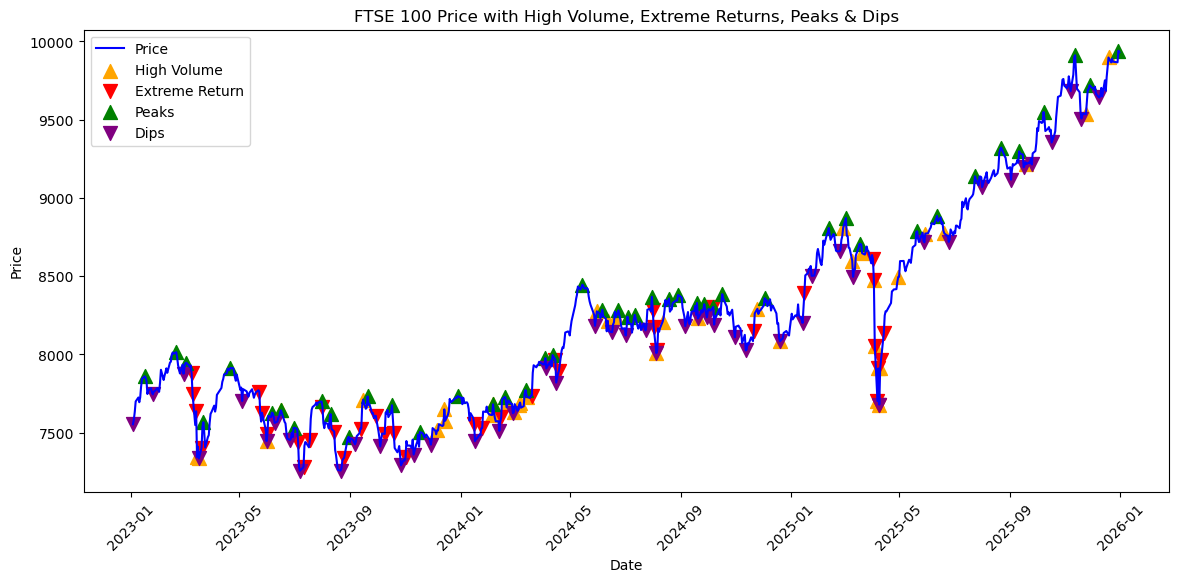

In [34]:
plt.figure(figsize=(14,6))
plt.plot(df_copy['Date'], df_copy['Price'], label='Price', color='blue')

# High Volume
plt.scatter(df_copy.loc[df_copy['High_Volume'], 'Date'],
            df_copy.loc[df_copy['High_Volume'], 'Price'],
            color='orange', label='High Volume', marker='^', s=100)

# Extreme Returns
plt.scatter(df_copy.loc[df_copy['Extreme_Return'], 'Date'],
            df_copy.loc[df_copy['Extreme_Return'], 'Price'],
            color='red', label='Extreme Return', marker='v', s=100)

# Peaks
plt.scatter(df_copy['Date'], df_copy['Peak'], color='green', label='Peaks', marker='^', s=100)

# Dips
plt.scatter(df_copy['Date'], df_copy['Dip'], color='purple', label='Dips', marker='v', s=100)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('FTSE 100 Price with High Volume, Extreme Returns, Peaks & Dips')
plt.legend()
plt.xticks(rotation=45)
plt.show()

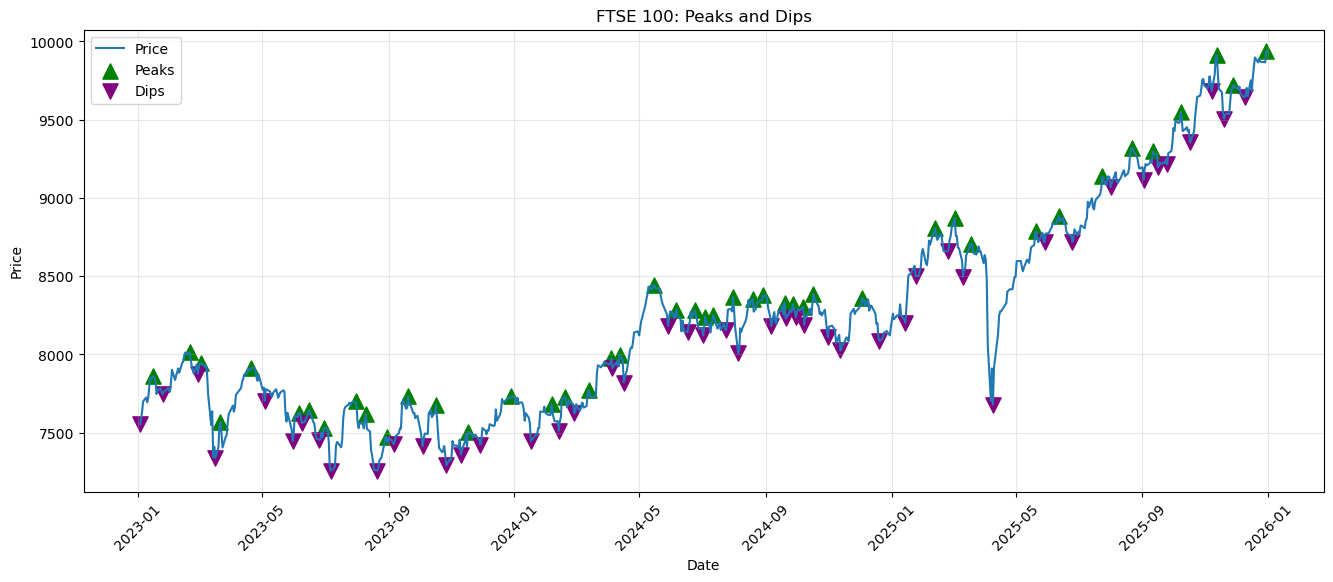

In [35]:
# Plot Peaks and Dips
plt.figure(figsize=(16,6))
plt.plot(df_copy['Date'], df_copy['Price'], label='Price')
plt.scatter(df_copy['Date'], df_copy['Peak'], color='green', label='Peaks', marker='^', s=120)
plt.scatter(df_copy['Date'], df_copy['Dip'], color='purple', label='Dips', marker='v', s=120)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('FTSE 100: Peaks and Dips')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

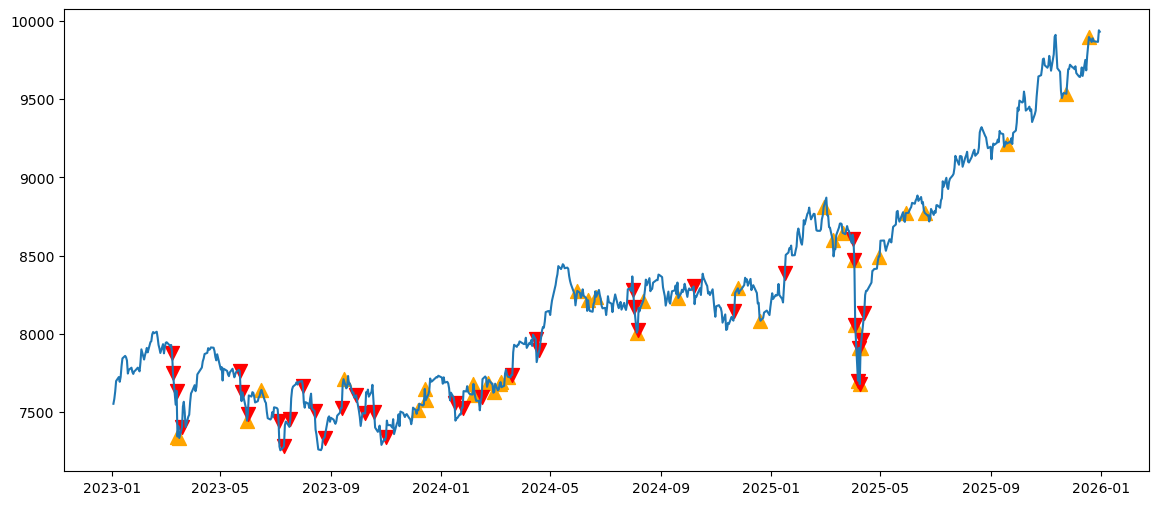

In [36]:
# High Volume
plt.figure(figsize=(14,6))
plt.plot(df_copy['Date'], df_copy['Price'], label='Price')
plt.scatter(df_copy.loc[df_copy['High_Volume'], 'Date'],
            df_copy.loc[df_copy['High_Volume'], 'Price'],
            color='orange', label='High Volume', marker='^', s=100)

# Extreme Returns
plt.scatter(df_copy.loc[df_copy['Extreme_Return'], 'Date'],
            df_copy.loc[df_copy['Extreme_Return'], 'Price'],
            color='red', label='Extreme Return', marker='v', s=100)

## Selecting Attributes

In [37]:
df_copy3 = df.copy()

In [38]:
df_copy3.head()

,Date,Price,Open,High,Low,Vol.,Change %,Returns,MA30,Volatility
0,2025-12-31,9931.38,9940.70,9950.11,9916.70,176050000.0,-0.09,NaN,NaN,NaN
1,2025-12-30,9940.71,9866.53,9954.32,9859.77,364740000.0,0.75,0.000939,NaN,NaN
2,2025-12-29,9866.53,9870.69,9892.79,9858.46,341170000.0,-0.04,-0.007462,NaN,NaN
3,2025-12-24,9870.68,9889.20,9893.15,9862.04,163410000.0,-0.19,0.000421,NaN,NaN
4,2025-12-23,9889.22,9865.94,9901.48,9846.29,534190000.0,0.24,0.001878,NaN,NaN


In [39]:
# Drop the columns from df_copy3
df_copy3 = df_copy3.drop(columns=['Returns', 'MA30', 'Volatility'], errors='ignore')


In [40]:
df_copy3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-12-31,9931.38,9940.70,9950.11,9916.70,176050000.0,-0.09
1,2025-12-30,9940.71,9866.53,9954.32,9859.77,364740000.0,0.75
2,2025-12-29,9866.53,9870.69,9892.79,9858.46,341170000.0,-0.04
3,2025-12-24,9870.68,9889.20,9893.15,9862.04,163410000.0,-0.19
4,2025-12-23,9889.22,9865.94,9901.48,9846.29,534190000.0,0.24


In [41]:
df_copy3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      758 non-null    datetime64[ns]
 1   Price     758 non-null    float64       
 2   Open      758 non-null    float64       
 3   High      758 non-null    float64       
 4   Low       758 non-null    float64       
 5   Vol.      758 non-null    float64       
 6   Change %  758 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 41.6 KB


# Interest Rate Dataset

In [42]:
df_2 = pd.read_csv("Bank of England.csv")
df_2.head()

,Date,Monthly average of UK resident banks' sterling weighted average interest rate - loans secured on dwellings with an initial fixation >10yrs to Individuals and individual trusts (in percent) not seasonally adjusted CFMZ6J5
0,31 Oct 25,2.78
1,30 Sep 25,2.78
2,31 Aug 25,2.76
3,31 Jul 25,2.78
4,30 Jun 25,2.79


In [43]:
df_2.columns

Index(['Date', 'Monthly average of UK resident banks' sterling weighted average interest rate - loans secured on dwellings with an initial fixation >10yrs to Individuals and individual trusts (in percent) not seasonally adjusted                          CFMZ6J5'], dtype='object')

In [44]:
monthly_col = df_2.columns[1] 
monthly_col

"Monthly average of UK resident banks' sterling weighted average interest rate - loans secured on dwellings with an initial fixation >10yrs to Individuals and individual trusts (in percent) not seasonally adjusted                          CFMZ6J5"

In [45]:
df_2.rename(columns={monthly_col: 'Monthly_Avg_UK'}, inplace=True)

In [46]:
df_2.head()

,Date,Monthly_Avg_UK
0,31 Oct 25,2.78
1,30 Sep 25,2.78
2,31 Aug 25,2.76
3,31 Jul 25,2.78
4,30 Jun 25,2.79


In [47]:
df_2.tail()

,Date,Monthly_Avg_UK
65,31 May 20,4.24
66,30 Apr 20,4.23
67,31 Mar 20,4.39
68,29 Feb 20,4.41
69,31 Jan 20,4.40


In [48]:
df_2.dtypes

Date               object
Monthly_Avg_UK    float64
dtype: object

In [49]:
# 1. Make sure column is string
df_2['Date'] = df_2['Date'].astype(str).str.strip()

# 2. Convert to datetime (correct format)
df_2['Date'] = pd.to_datetime(
    df_2['Date'],
    format='%d %b %y',
    dayfirst=True
)

# 3. Verify
df_2.dtypes

Date              datetime64[ns]
Monthly_Avg_UK           float64
dtype: object

In [50]:
df_2.columns

Index(['Date', 'Monthly_Avg_UK'], dtype='object')

In [52]:
df_2.info

<bound method DataFrame.info of          Date  Monthly_Avg_UK
0  2025-10-31            2.78
1  2025-09-30            2.78
2  2025-08-31            2.76
3  2025-07-31            2.78
4  2025-06-30            2.79
..        ...             ...
65 2020-05-31            4.24
66 2020-04-30            4.23
67 2020-03-31            4.39
68 2020-02-29            4.41
69 2020-01-31            4.40

[70 rows x 2 columns]>

## Time Series 

In [53]:
start_date = pd.Timestamp('2023-01-01')
end_date   = pd.Timestamp('2025-12-31')

df_2 = df_2.loc[
    (df_2['Date'] >= start_date) &
    (df_2['Date'] <= end_date)
].reset_index(drop=True)

In [54]:
df_2['Date'].min(), df_2['Date'].max()

(Timestamp('2023-01-31 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [55]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            34 non-null     datetime64[ns]
 1   Monthly_Avg_UK  34 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 676.0 bytes


In [56]:
df_2.info

<bound method DataFrame.info of          Date  Monthly_Avg_UK
0  2025-10-31            2.78
1  2025-09-30            2.78
2  2025-08-31            2.76
3  2025-07-31            2.78
4  2025-06-30            2.79
5  2025-05-31            2.77
6  2025-04-30            2.76
7  2025-03-31            2.76
8  2025-02-28            2.80
9  2025-01-31            2.80
10 2024-12-31            2.79
11 2024-11-30            2.78
12 2024-10-31            2.77
13 2024-09-30            2.77
14 2024-08-31            2.82
15 2024-07-31            2.77
16 2024-06-30            2.76
17 2024-05-31            2.76
18 2024-04-30            2.62
19 2024-03-31            2.63
20 2024-02-29            2.61
21 2024-01-31            2.67
22 2023-12-31            2.63
23 2023-11-30            2.75
24 2023-10-31            2.74
25 2023-09-30            2.73
26 2023-08-31            2.76
27 2023-07-31            2.74
28 2023-06-30            2.73
29 2023-05-31            2.75
30 2023-04-30            2.68
31 2023-

## Cleaned Dataframe

In [57]:
df_2

,Date,Monthly_Avg_UK
0,2025-10-31,2.78
1,2025-09-30,2.78
2,2025-08-31,2.76
3,2025-07-31,2.78
4,2025-06-30,2.79
5,2025-05-31,2.77
6,2025-04-30,2.76
7,2025-03-31,2.76
8,2025-02-28,2.80
9,2025-01-31,2.80


# Inflation Dataset

In [58]:
df_3 = pd.read_csv("CPI.csv")

In [59]:
df_3.head()

,Unnamed: 0,L522,L55O,D7BT,D7G7,CHAW,CZBH
0,Nov 2022,124.8,9.3,126.7,10.7,358.3,14.0
1,Dec,125.3,9.2,127.2,10.5,360.4,13.4
2,Jan,124.8,8.8,126.4,10.1,360.3,13.4
3,Feb,126.0,9.2,127.9,10.4,364.5,13.8
4,Mar,126.8,8.9,128.9,10.1,367.2,13.5


In [60]:
 df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  37 non-null     object 
 1   L522        37 non-null     float64
 2   L55O        37 non-null     float64
 3    D7BT       37 non-null     float64
 4    D7G7       37 non-null     float64
 5    CHAW       37 non-null     float64
 6    CZBH       37 non-null     float64
dtypes: float64(6), object(1)
memory usage: 2.2+ KB


In [61]:
# 1️⃣ Make a copy of df_3
df_3_copy_clean = df_3.copy()

In [62]:
df_3_copy_clean.info

<bound method DataFrame.info of    Unnamed: 0   L522  L55O   D7BT   D7G7   CHAW   CZBH
0    Nov 2022  124.8   9.3  126.7   10.7  358.3   14.0
1        Dec   125.3   9.2  127.2   10.5  360.4   13.4
2        Jan   124.8   8.8  126.4   10.1  360.3   13.4
3        Feb   126.0   9.2  127.9   10.4  364.5   13.8
4        Mar   126.8   8.9  128.9   10.1  367.2   13.5
5         Apr  128.3   7.8  130.4    8.7  372.8   11.4
6        May   129.1   7.9  131.3    8.7  375.3   11.3
7        Jun   129.4   7.3  131.5    7.9  376.4   10.7
8        Jul   129.0   6.4  130.9    6.8  374.2    9.0
9         Aug  129.4   6.3  131.3    6.7  376.6    9.1
10       Sep   130.1   6.3  132.0    6.7  378.4    8.9
11        Oct  130.2   4.7  132.0    4.6  377.8    6.1
12   Nov 2023  130.0   4.2  131.7    3.9  377.3    5.3
13        Dec  130.5   4.2  132.2    4.0  379.0    5.2
14       Jan   130.0   4.2  131.5    4.0  378.0    4.9
15        Feb  130.8   3.8  132.3    3.4  381.0    4.5
16       Mar   131.6   3.8  133.0

## Data Cleaning

In [63]:
# Create clean monthly dataframe
df_3_copy_clean = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', end='2025-10-31', freq='M')
})

print(df_3_copy_clean.head())
print(df_3_copy_clean.tail())

        Date
0 2023-01-31
1 2023-02-28
2 2023-03-31
3 2023-04-30
4 2023-05-31
         Date
29 2025-06-30
30 2025-07-31
31 2025-08-31
32 2025-09-30
33 2025-10-31


In [64]:
df_3_copy_clean

,Date
0,2023-01-31
1,2023-02-28
2,2023-03-31
3,2023-04-30
4,2023-05-31
5,2023-06-30
6,2023-07-31
7,2023-08-31
8,2023-09-30
9,2023-10-31


In [65]:
 df_3_copy = df_3.copy()

In [66]:
# 1️⃣ Slice rows 2 → 35
df_3_copy = df_3_copy.iloc[2:36].copy()  # 36 is exclusive

# 2️⃣ Drop the Unnamed column
unnamed_cols = [col for col in df_3_copy.columns if 'Unnamed' in col]
df_3_copy.drop(columns=unnamed_cols, inplace=True)

# 3️⃣ Reset index
df_3_copy = df_3_copy.reset_index(drop=True)

# 4️⃣ Check
print(df_3_copy.head())
print(df_3_copy.tail())
print(df_3_copy.shape)  # should be 34 rows

    L522  L55O   D7BT   D7G7   CHAW   CZBH
0  124.8   8.8  126.4   10.1  360.3   13.4
1  126.0   9.2  127.9   10.4  364.5   13.8
2  126.8   8.9  128.9   10.1  367.2   13.5
3  128.3   7.8  130.4    8.7  372.8   11.4
4  129.1   7.9  131.3    8.7  375.3   11.3
     L522  L55O   D7BT   D7G7   CHAW   CZBH
29  138.4   4.1  138.9    3.6  404.5    4.4
30  138.5   4.2  139.0    3.8  406.2    4.8
31  138.9   4.1  139.3    3.8  407.7    4.6
32  138.9   4.1  139.3    3.8  406.1    4.5
33  139.5   3.8  139.8    3.6  407.4    4.3
(34, 6)


In [67]:
# Make sure both dataframes have the same number of rows
assert len(df_3_copy_clean) == len(df_3_copy), "Row counts must match!"

# Combine columns from df_3_copy into df_3_copy_clean
df_merged = pd.concat([df_3_copy_clean.reset_index(drop=True),
                       df_3_copy.reset_index(drop=True)], axis=1)

# Check result
print(df_merged.head())
print(df_merged.tail())
print(df_merged.shape)  # should be 34 row


        Date   L522  L55O   D7BT   D7G7   CHAW   CZBH
0 2023-01-31  124.8   8.8  126.4   10.1  360.3   13.4
1 2023-02-28  126.0   9.2  127.9   10.4  364.5   13.8
2 2023-03-31  126.8   8.9  128.9   10.1  367.2   13.5
3 2023-04-30  128.3   7.8  130.4    8.7  372.8   11.4
4 2023-05-31  129.1   7.9  131.3    8.7  375.3   11.3
         Date   L522  L55O   D7BT   D7G7   CHAW   CZBH
29 2025-06-30  138.4   4.1  138.9    3.6  404.5    4.4
30 2025-07-31  138.5   4.2  139.0    3.8  406.2    4.8
31 2025-08-31  138.9   4.1  139.3    3.8  407.7    4.6
32 2025-09-30  138.9   4.1  139.3    3.8  406.1    4.5
33 2025-10-31  139.5   3.8  139.8    3.6  407.4    4.3
(34, 7)


In [68]:
df_copy['Date'] = pd.to_datetime(df_copy['Date'])

In [69]:
df_copy = df_copy.set_index('Date')

In [70]:
df_copy = df_copy.resample('M').last()

In [71]:
df_copy = df_copy.reset_index()

In [72]:
df_copy.head()

,Date,Price,Open,High,Low,Vol.,Change %,Returns,MA30,Volatility,High_Volume,Extreme_Return,Peak,Dip
0,2023-01-31,7771.70,7784.87,7784.87,7708.34,8.289200e+08,-0.17,0.001364,7894.460667,0.007800,False,False,7860.07,7744.87
1,2023-02-28,7876.28,7935.11,7935.11,7854.82,1.250000e+09,-0.74,-0.004883,7662.416667,0.011910,False,False,8014.31,7876.28
2,2023-03-31,7631.74,7620.43,7654.41,7616.09,8.158500e+08,0.15,-0.005377,7793.908000,0.005140,False,False,7566.84,7335.40
3,2023-04-30,7870.57,7831.58,7870.57,7791.63,9.429700e+08,0.50,0.012549,7675.322000,0.007117,False,False,7914.13,NaN
4,2023-05-31,7446.14,7522.07,7522.07,7446.14,2.280000e+09,-1.01,-0.005892,7509.328667,0.007301,True,False,NaN,7446.14


In [73]:
df_copy = df_copy.drop(columns=['Returns', 'MA30', 'Volatility', 'High_Volume', 'Extreme_Return', 'Peak', 'Dip'], errors='ignore')

In [74]:
df_copy

,Date,Price,Open,High,Low,Vol.,Change %
0,2023-01-31,7771.70,7784.87,7784.87,7708.34,8.289200e+08,-0.17
1,2023-02-28,7876.28,7935.11,7935.11,7854.82,1.250000e+09,-0.74
2,2023-03-31,7631.74,7620.43,7654.41,7616.09,8.158500e+08,0.15
3,2023-04-30,7870.57,7831.58,7870.57,7791.63,9.429700e+08,0.50
4,2023-05-31,7446.14,7522.07,7522.07,7446.14,2.280000e+09,-1.01
5,2023-06-30,7531.53,7471.69,7551.59,7471.69,7.292000e+08,0.80
6,2023-07-31,7699.41,7694.27,7722.92,7667.81,5.936900e+08,0.07
7,2023-08-31,7439.13,7473.67,7500.44,7439.13,1.140000e+09,-0.46
8,2023-09-30,7608.08,7601.85,7674.19,7601.85,6.335900e+08,0.08
9,2023-10-31,7321.72,7327.39,7373.53,7309.04,8.053400e+08,-0.08


In [75]:
df_copy['Date'] = pd.to_datetime(df_copy['Date'])
df_copy = df_copy.set_index('Date')
df_copy = df_copy.resample('M').last()
df_copy = df_copy.loc['2023-01-01':'2025-10-31']
df_copy = df_copy.reset_index()

In [76]:
df_copy

,Date,Price,Open,High,Low,Vol.,Change %
0,2023-01-31,7771.70,7784.87,7784.87,7708.34,8.289200e+08,-0.17
1,2023-02-28,7876.28,7935.11,7935.11,7854.82,1.250000e+09,-0.74
2,2023-03-31,7631.74,7620.43,7654.41,7616.09,8.158500e+08,0.15
3,2023-04-30,7870.57,7831.58,7870.57,7791.63,9.429700e+08,0.50
4,2023-05-31,7446.14,7522.07,7522.07,7446.14,2.280000e+09,-1.01
5,2023-06-30,7531.53,7471.69,7551.59,7471.69,7.292000e+08,0.80
6,2023-07-31,7699.41,7694.27,7722.92,7667.81,5.936900e+08,0.07
7,2023-08-31,7439.13,7473.67,7500.44,7439.13,1.140000e+09,-0.46
8,2023-09-30,7608.08,7601.85,7674.19,7601.85,6.335900e+08,0.08
9,2023-10-31,7321.72,7327.39,7373.53,7309.04,8.053400e+08,-0.08


In [77]:
df_merged

,Date,L522,L55O,D7BT,D7G7,CHAW,CZBH
0,2023-01-31,124.8,8.8,126.4,10.1,360.3,13.4
1,2023-02-28,126.0,9.2,127.9,10.4,364.5,13.8
2,2023-03-31,126.8,8.9,128.9,10.1,367.2,13.5
3,2023-04-30,128.3,7.8,130.4,8.7,372.8,11.4
4,2023-05-31,129.1,7.9,131.3,8.7,375.3,11.3
5,2023-06-30,129.4,7.3,131.5,7.9,376.4,10.7
6,2023-07-31,129.0,6.4,130.9,6.8,374.2,9.0
7,2023-08-31,129.4,6.3,131.3,6.7,376.6,9.1
8,2023-09-30,130.1,6.3,132.0,6.7,378.4,8.9
9,2023-10-31,130.2,4.7,132.0,4.6,377.8,6.1


In [78]:
type(df_merged)

pandas.core.frame.DataFrame

In [79]:
df_merged.columns = df_merged.columns.str.strip()

# Rename CPI/RPI columns
df_merged.rename(columns={
    'L522': 'CPIH_index',
    'L55O': 'CPIH_change',
    'D7BT': 'CPI_index',
    'D7G7': 'CPI_change',
    'CHAW': 'RPI_index',
    'CZBH': 'RPI_change'
}, inplace=True)

# Verify
print(df_merged.columns.tolist())

['Date', 'CPIH_index', 'CPIH_change', 'CPI_index', 'CPI_change', 'RPI_index', 'RPI_change']


## CPI Dataframe 

In [80]:
df_merged

,Date,CPIH_index,CPIH_change,CPI_index,CPI_change,RPI_index,RPI_change
0,2023-01-31,124.8,8.8,126.4,10.1,360.3,13.4
1,2023-02-28,126.0,9.2,127.9,10.4,364.5,13.8
2,2023-03-31,126.8,8.9,128.9,10.1,367.2,13.5
3,2023-04-30,128.3,7.8,130.4,8.7,372.8,11.4
4,2023-05-31,129.1,7.9,131.3,8.7,375.3,11.3
5,2023-06-30,129.4,7.3,131.5,7.9,376.4,10.7
6,2023-07-31,129.0,6.4,130.9,6.8,374.2,9.0
7,2023-08-31,129.4,6.3,131.3,6.7,376.6,9.1
8,2023-09-30,130.1,6.3,132.0,6.7,378.4,8.9
9,2023-10-31,130.2,4.7,132.0,4.6,377.8,6.1


## FTSE 100

In [81]:
df_copy

,Date,Price,Open,High,Low,Vol.,Change %
0,2023-01-31,7771.70,7784.87,7784.87,7708.34,8.289200e+08,-0.17
1,2023-02-28,7876.28,7935.11,7935.11,7854.82,1.250000e+09,-0.74
2,2023-03-31,7631.74,7620.43,7654.41,7616.09,8.158500e+08,0.15
3,2023-04-30,7870.57,7831.58,7870.57,7791.63,9.429700e+08,0.50
4,2023-05-31,7446.14,7522.07,7522.07,7446.14,2.280000e+09,-1.01
5,2023-06-30,7531.53,7471.69,7551.59,7471.69,7.292000e+08,0.80
6,2023-07-31,7699.41,7694.27,7722.92,7667.81,5.936900e+08,0.07
7,2023-08-31,7439.13,7473.67,7500.44,7439.13,1.140000e+09,-0.46
8,2023-09-30,7608.08,7601.85,7674.19,7601.85,6.335900e+08,0.08
9,2023-10-31,7321.72,7327.39,7373.53,7309.04,8.053400e+08,-0.08


## Bank Interest 

In [82]:
df_2

,Date,Monthly_Avg_UK
0,2025-10-31,2.78
1,2025-09-30,2.78
2,2025-08-31,2.76
3,2025-07-31,2.78
4,2025-06-30,2.79
5,2025-05-31,2.77
6,2025-04-30,2.76
7,2025-03-31,2.76
8,2025-02-28,2.80
9,2025-01-31,2.80


## Export Dataset 

In [83]:
df_copy.to_csv(r"D:\MacroMarketAnalysis\ftse_100.csv", index=False)

In [84]:
df_merged.to_csv(r"D:\MacroMarketAnalysis\cpi.csv", index=False)

In [85]:
df_2.to_csv(r"D:\MacroMarketAnalysis\bankinterest.csv", index=False)

In [86]:
df_m = pd.read_csv("macro_analysis.csv")

In [87]:
df_m.head()

,2023-01-31,7771.7001953125,7784.8701171875,7784.8701171875.1,7708.33984375,828920000,-0.170000001788139,124.800003051758,8.80000019073486,126.400001525879,10.1000003814697,360.299987792969,13.3999996185303,2.6800000667572
0,2023-02-28,7876.279785,7935.109863,7935.109863,7854.819824,1250000000,-0.74,126.000000,9.2,127.900002,10.4,364.500000,13.8,2.71
1,2023-03-31,7631.740234,7620.430176,7654.410156,7616.089844,815849984,0.15,126.800003,8.9,128.899994,10.1,367.200012,13.5,2.71
2,2023-04-30,7870.569824,7831.580078,7870.569824,7791.629883,942969984,0.50,128.300003,7.8,130.399994,8.7,372.799988,11.4,2.68
3,2023-05-31,7446.140137,7522.069824,7522.069824,7446.140137,2280000000,-1.01,129.100006,7.9,131.300003,8.7,375.299988,11.3,2.75
4,2023-06-30,7531.529785,7471.689941,7551.589844,7471.689941,729200000,0.80,129.399994,7.3,131.500000,7.9,376.399994,10.7,2.73


## Processed Data

In [5]:
df_p = pd.read_excel("macro_data.xlsx")

In [7]:
df_p.head()

,Date,Price,Open,High,Low,Vol,FTSE_Change_pct,CPIH_index,CPIH_change,CPI_index,CPI_change,RPI_index,RPI_change,Bank_Rate
0,2023-01-31,7771.700195,7784.870117,7784.870117,7708.339844,828920000,-0.17,124.800003,8.8,126.400002,10.1,360.299988,13.4,2.68
1,2023-02-28,7876.279785,7935.109863,7935.109863,7854.819824,1250000000,-0.74,126.000000,9.2,127.900002,10.4,364.500000,13.8,2.71
2,2023-03-31,7631.740234,7620.430176,7654.410156,7616.089844,815849984,0.15,126.800003,8.9,128.899994,10.1,367.200012,13.5,2.71
3,2023-04-30,7870.569824,7831.580078,7870.569824,7791.629883,942969984,0.50,128.300003,7.8,130.399994,8.7,372.799988,11.4,2.68
4,2023-05-31,7446.140137,7522.069824,7522.069824,7446.140137,2280000000,-1.01,129.100006,7.9,131.300003,8.7,375.299988,11.3,2.75


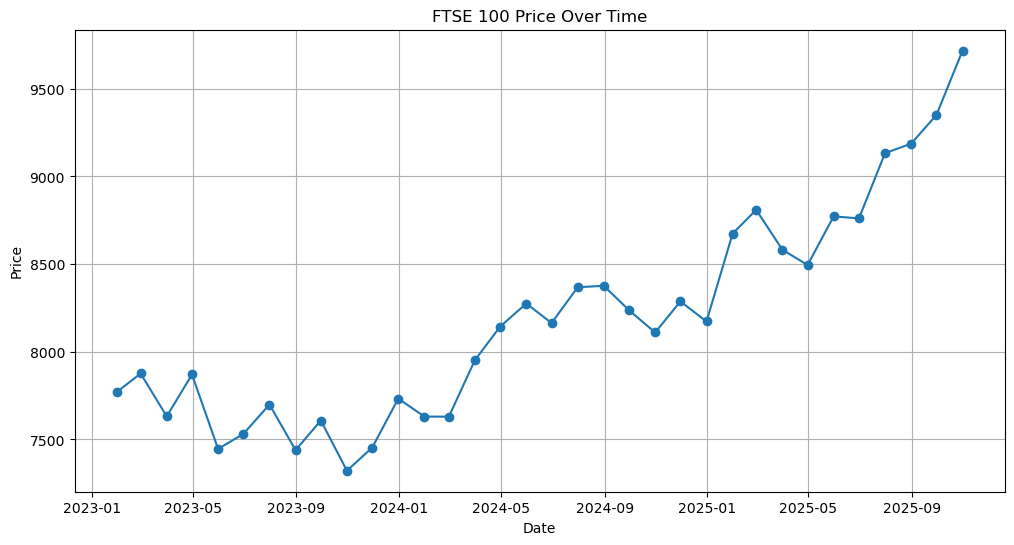

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df_p['Date'], df_p['Price'], marker='o')
plt.title('FTSE 100 Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

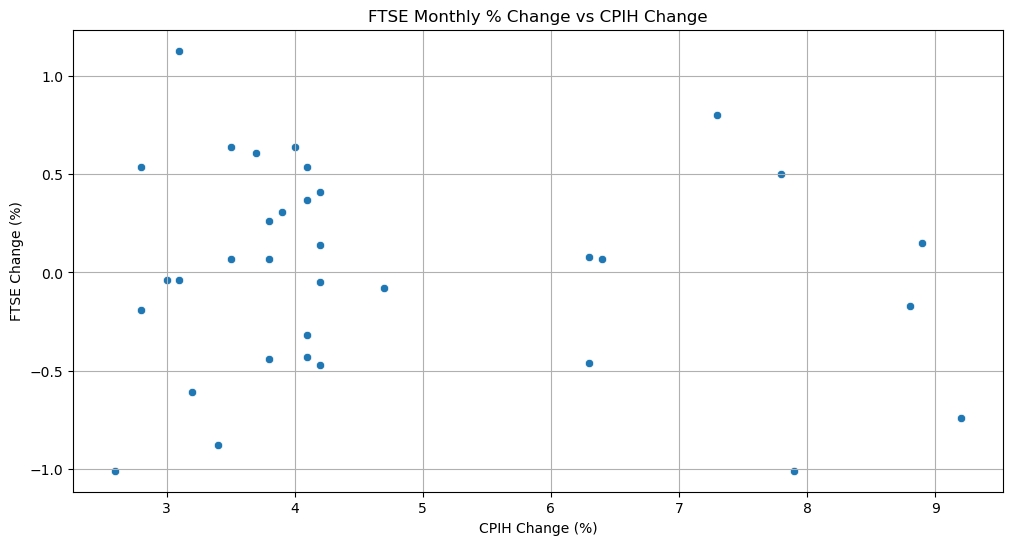

In [12]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='CPIH_change', y='FTSE_Change_pct', data=df_p)
plt.title('FTSE Monthly % Change vs CPIH Change')
plt.xlabel('CPIH Change (%)')
plt.ylabel('FTSE Change (%)')
plt.grid(True)
plt.show()

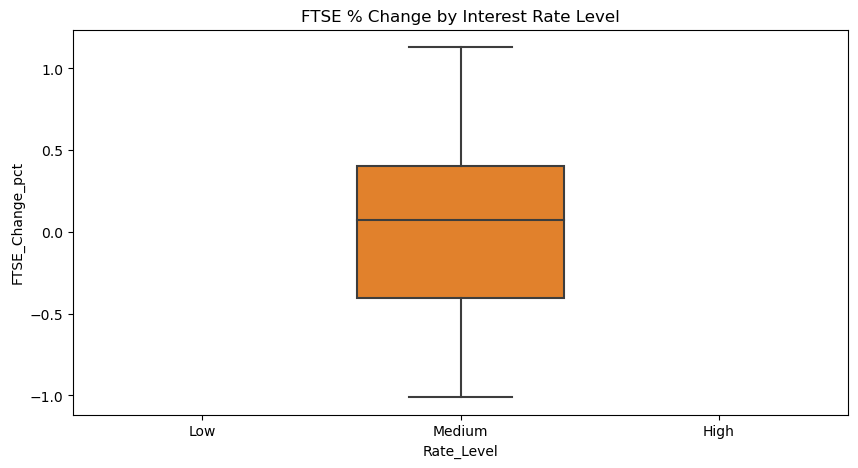

In [15]:
df_p['Rate_Level'] = pd.cut(df_p['Bank_Rate'], bins=[-1, 1.5, 3, 100], labels=['Low','Medium','High'])

plt.figure(figsize=(10,5))
sns.boxplot(x='Rate_Level', y='FTSE_Change_pct', data=df_p)
plt.title('FTSE % Change by Interest Rate Level')
plt.show()

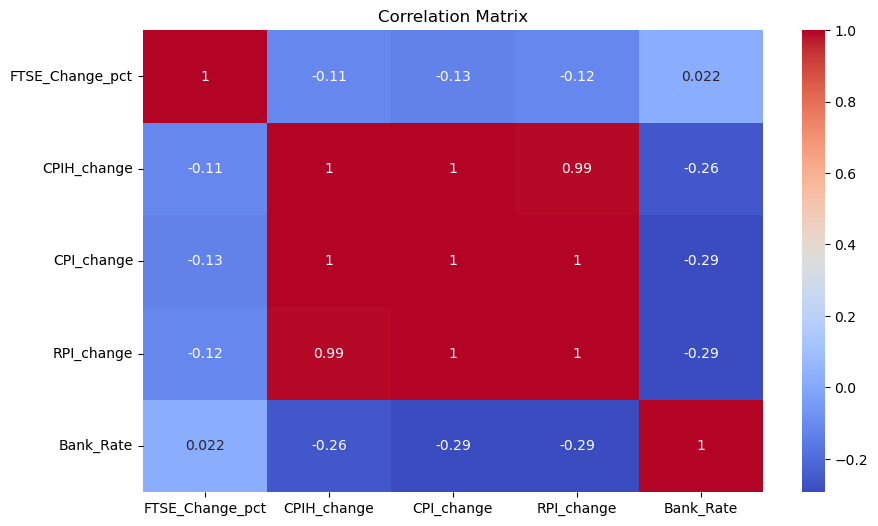

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df_p[['FTSE_Change_pct','CPIH_change','CPI_change','RPI_change','Bank_Rate']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()